# Notebook exploratorio para aplicar T-sne, ISOMAP, LLE a los vectores topoloógicos de 82 contigs plasmidicos de distintos genomas

## Librerías necesarias

In [73]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn import manifold
from sklearn.manifold import LocallyLinearEmbedding

## Datos

In [5]:
df_Optimizado = pd.read_csv("/files2/gerardo/KmerTopology/data/processed/optimized_pipeline/vectors_topB_escherichia.csv", header=None)

In [6]:
vect_E = df_Optimizado.to_numpy()

In [7]:
#Accesion (id del genoma)
id_column="name"

df_ids = pd.read_csv("/files2/gerardo/KmerTopology/data/processed/optimized_pipeline/escherichia_plasmid_82.csv")

ids = df_ids[id_column].astype(str).tolist()

In [8]:
# Manifiesto, accesion+fenotipo
id_column="accession"
label_column="phenotype"

df_manifest = pd.read_csv("/files2/gerardo/KmerTopology/data/processed/selected_genomes/plasmid_manifest.csv", dtype=str)

df_manifest = df_manifest.dropna(subset=[id_column, label_column])

label_lookup = dict(zip(df_manifest[id_column].astype(str), df_manifest[label_column].astype(str)))

### Hacer el cruze de los accesion y su estado (Resistencia o Suceptibilidad)

In [9]:
if len(ids) == len(vect_E):
    print("Misma cantidad de datos")

Misma cantidad de datos


In [10]:
keep_idx = []
ids_sin_label = []

for i, accession in enumerate(ids):
    if accession in label_lookup:
        keep_idx.append(i)
    else:
        print(accession)
        ids_sin_label.append(accession)

X = vect_E[keep_idx]
ids_usados = [ids[i] for i in keep_idx]
labels_usados = np.array([label_lookup[a] for a in ids_usados])

# return X, ids_usados, labels_usados, ids_sin_label

In [11]:
print(labels_usados)

['susceptible' 'susceptible' 'susceptible' 'susceptible' 'resistant'
 'resistant' 'resistant' 'susceptible' 'susceptible' 'resistant'
 'resistant' 'susceptible' 'susceptible' 'intermediate' 'susceptible'
 'susceptible' 'resistant' 'resistant' 'resistant' 'resistant'
 'intermediate' 'resistant' 'resistant' 'resistant' 'resistant'
 'susceptible' 'susceptible' 'resistant' 'susceptible' 'susceptible'
 'susceptible' 'susceptible' 'resistant' 'resistant' 'resistant'
 'intermediate' 'susceptible' 'resistant' 'susceptible' 'resistant'
 'resistant' 'susceptible' 'susceptible' 'resistant' 'susceptible'
 'susceptible' 'intermediate' 'susceptible' 'resistant' 'resistant'
 'susceptible' 'susceptible' 'susceptible' 'resistant' 'resistant'
 'resistant' 'intermediate' 'resistant' 'susceptible' 'susceptible'
 'susceptible' 'susceptible' 'susceptible' 'susceptible' 'resistant'
 'susceptible' 'resistant' 'resistant' 'susceptible' 'susceptible'
 'resistant' 'intermediate' 'susceptible' 'resistant' 'suscep

## t-SNE

In [46]:
tsne = TSNE(
    n_components=3,
    perplexity=25,
    learning_rate=100,
    random_state=42
)

In [52]:
vect_E_tsne = tsne.fit_transform(vect_E)

X_plot = vect_E_tsne
X_plot.shape
X_plot_2d = X_plot[:, :2]

/opt/conda/envs/TDA/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,


## ISOMAP

In [70]:
iso = manifold.Isomap(n_neighbors=25, n_components=2)

In [71]:
X_iso = iso.fit_transform(vect_E)
#X_iso = X_iso*12

## Local Linear Embending

In [91]:
lle = LocallyLinearEmbedding(
    n_neighbors=10,
    n_components=2,
    method='standard',
    random_state=42
)

In [92]:
X_lle = lle.fit_transform(vect_E)

## Visualizacion

In [21]:
def label_colors(labels):
    """Asigna un color determinista a cada fenotipo."""
    
    unique_labels = sorted(set(labels))
    
    if len(unique_labels) == 2:
        palette = ["#d62728", "#1f77b4"]  # rojo, azul
    else:
        import matplotlib.cm as cm
        cmap = cm.get_cmap("tab10", max(len(unique_labels), 3))
        palette = [cmap(i) for i in range(len(unique_labels))]
    
    return {
        lab: palette[i % len(palette)]
        for i, lab in enumerate(unique_labels)
    }


def plot_label_scatter(
    coords,
    labels,
    out_path,
    title,
    ids=None,
    annotate=False,
    markers_by=None,
    marker_map=None,
    xlabel="Componente 1",
    ylabel="Componente 2",
    show=True
):
    colors = label_colors(labels)

    fig, ax = plt.subplots(figsize=(8, 6))

    if markers_by is not None:
        marker_map = marker_map or {}
        default_marker = "o"
        categories = sorted(set(markers_by))

        for cat in categories:
            marker = marker_map.get(cat, default_marker)
            mask = np.array([m == cat for m in markers_by])

            for lab in sorted(set(labels)):
                lab_mask = mask & (np.array(labels) == lab)

                if lab_mask.any():
                    ax.scatter(
                        coords[lab_mask, 0],
                        coords[lab_mask, 1],
                        c=[colors[lab]],
                        marker=marker,
                        label=f"{lab} ({cat})",
                        edgecolor="black",
                        linewidths=0.4,
                        s=60,
                    )

    else:
        for lab in sorted(set(labels)):
            mask = np.array(labels) == lab

            ax.scatter(
                coords[mask, 0],
                coords[mask, 1],
                c=[colors[lab]],
                label=str(lab),
                edgecolor="black",
                linewidths=0.4,
                s=60,
            )

    if annotate and ids is not None:
        for (x, y), acc in zip(coords, ids):
            ax.annotate(
                acc,
                (x, y),
                fontsize=6,
                alpha=0.7,
                xytext=(3, 3),
                textcoords="offset points"
            )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8, loc="best")

    fig.tight_layout()

    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    # Guardar
    fig.savefig(out_path, dpi=300)

    # Mostrar en el notebook
    if show:
        plt.show()

    plt.close(fig)

### T-sen

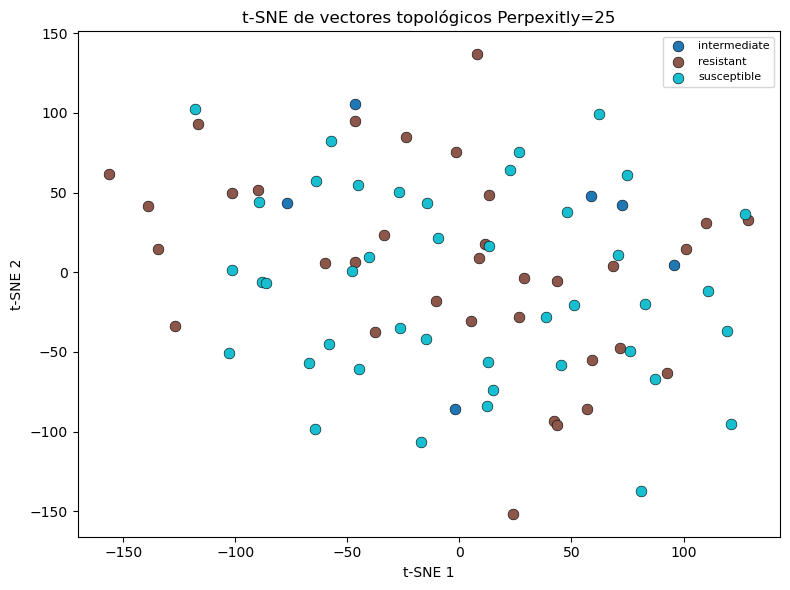

In [50]:
plot_label_scatter(
    coords=X_plot_2d,
    labels=labels_usados,
    ids=ids_usados,
    annotate=False,
    out_path="/files2/gerardo/KmerTopology/results/figures/optimized_pipeline/tsne_fenotipo_25.png",
    title="t-SNE de vectores topológicos Perpexitly=25",
    xlabel="t-SNE 1",
    ylabel="t-SNE 2",
    show=True
)

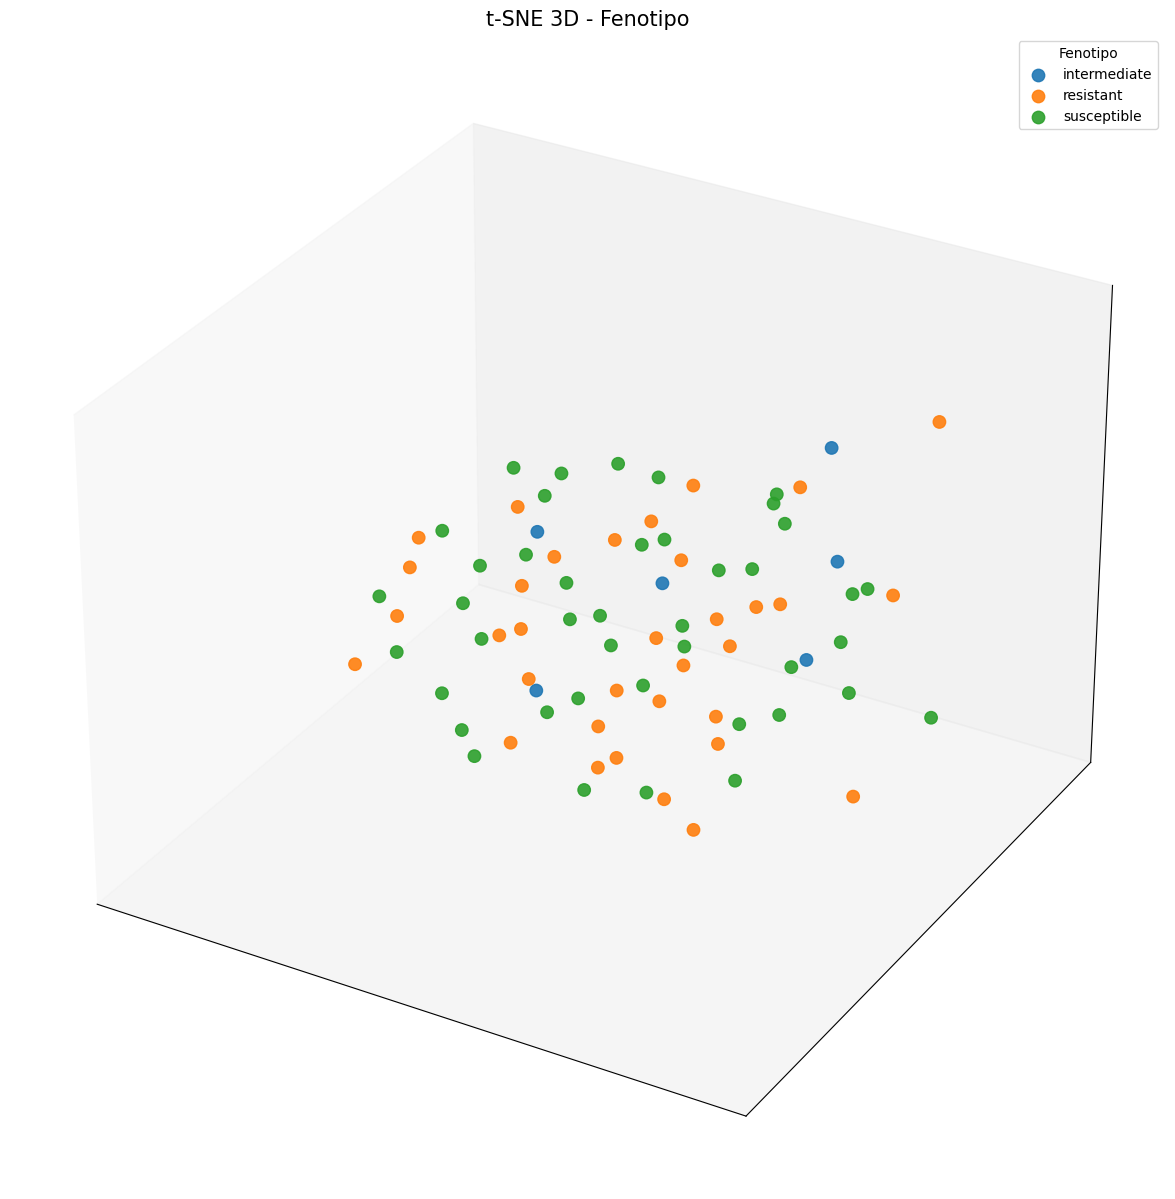

In [51]:
fig = plt.figure(figsize=(18, 15))
ax = fig.add_subplot(111, projection="3d")

for label in sorted(set(labels_usados)):
    mask = np.array(labels_usados) == label

    ax.scatter(
        X_plot[mask, 0],
        X_plot[mask, 1],
        X_plot[mask, 2],
        label=label,
        s=80,
        alpha=0.9
    )

ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

ax.set_title("t-SNE 3D - Fenotipo", fontsize=15)

ax.legend(title="Fenotipo")

plt.show()

### Isomap

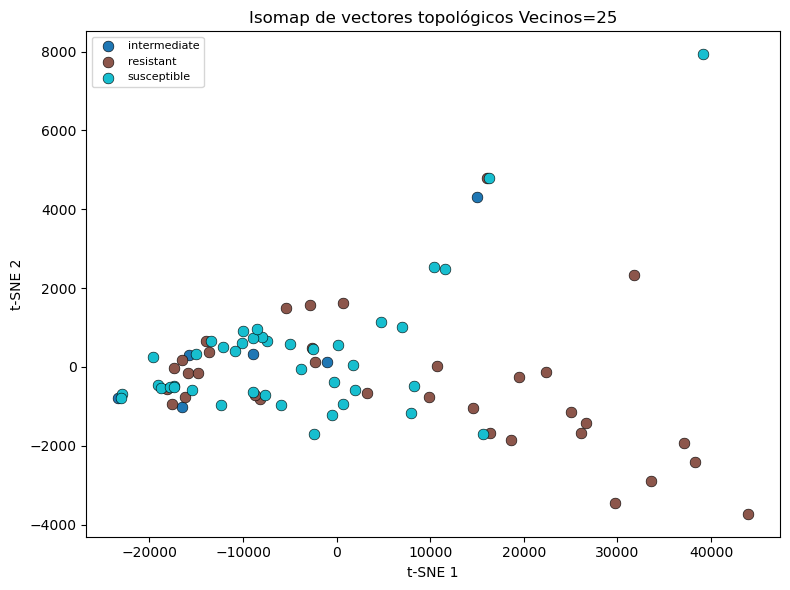

In [80]:
plot_label_scatter(
    coords=X_iso,
    labels=labels_usados,
    ids=ids_usados,
    annotate=False,
    out_path="/files2/gerardo/KmerTopology/results/figures/optimized_pipeline/Isomap_fenotipo_25.png",
    title="Isomap de vectores topológicos Vecinos=25",
    xlabel="t-SNE 1",
    ylabel="t-SNE 2",
    show=True
)

### LLE

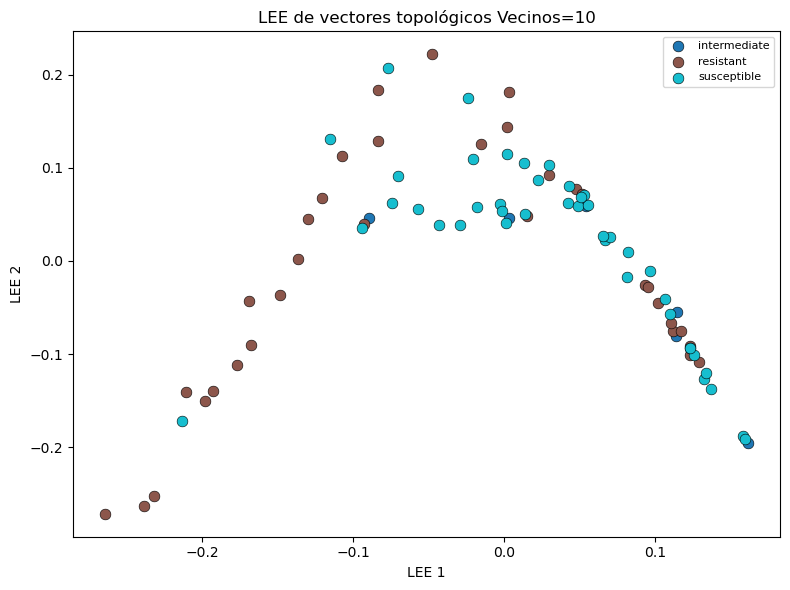

In [93]:
plot_label_scatter(
    coords=X_lle,
    labels=labels_usados,
    ids=ids_usados,
    annotate=False,
    out_path="/files2/gerardo/KmerTopology/results/figures/optimized_pipeline/LLE_fenotipo_10.png",
    title="LEE de vectores topológicos Vecinos=10",
    xlabel="LEE 1",
    ylabel="LEE 2",
    show=True
)